In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/teertha/ushealthinsurancedataset/insurance.csv


In [2]:
data = pd.read_csv('/kaggle/input/datasets/teertha/ushealthinsurancedataset/insurance.csv')

## 1. Understanding Data

In [3]:
df = pd.DataFrame(data)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## 2. Data Cleaning

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
# Removing Outliers in 'bmi' 
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['bmi'] >= Q1 - 1.5 * IQR) &
    (df['bmi'] <= Q3 + 1.5 * IQR)
]

In [11]:
df.shape

(1328, 7)

In [12]:
# # Removing Outliers in 'bmi' 
# Q1 = df['charges'].quantile(0.25)
# Q3 = df['charges'].quantile(0.75)
# IQR = Q3 - Q1

# df = df[
#     (df['charges'] >= Q1 - 1.5 * IQR) &
#     (df['charges'] <= Q3 + 1.5 * IQR)
# ]

##### As the data is already cleaned so we directly jump into EDA

# 3. EDA
## 3.1 Univariate Analysis

<Axes: xlabel='age', ylabel='Count'>

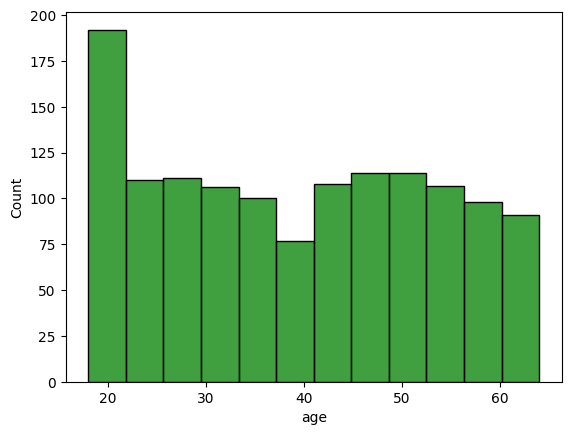

In [13]:
sns.histplot(df['age'],color='g',edgecolor='black')

#### Individuals aged 18–22 represent the largest insurance demographic

<Axes: xlabel='sex', ylabel='count'>

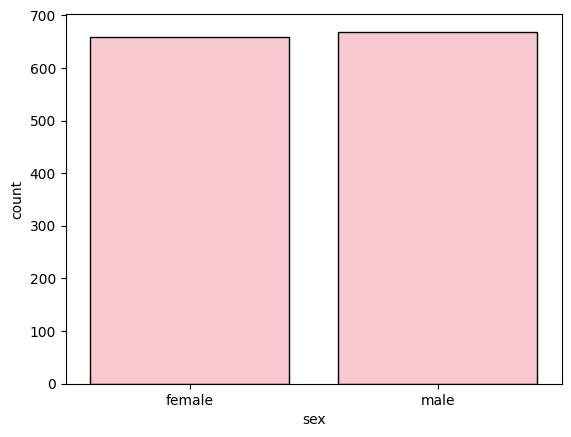

In [14]:
sns.countplot(x = df['sex'],color='pink',edgecolor='black')

#### This shows data is almost equally distributed

<Axes: xlabel='bmi', ylabel='Count'>

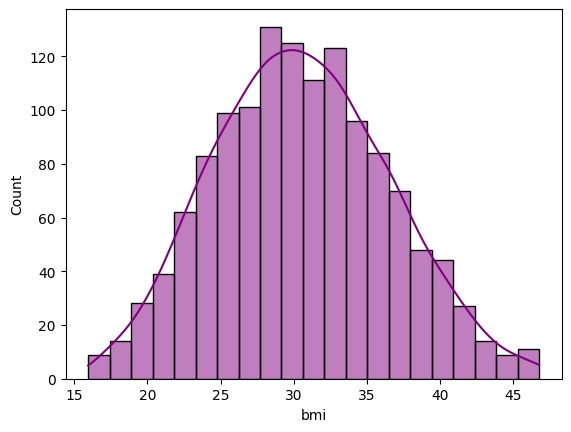

In [15]:
sns.histplot(
    df['bmi'],
    color='purple',
    edgecolor='black',
    kde=True
)

#### BMI almost Follows bell-Curve 

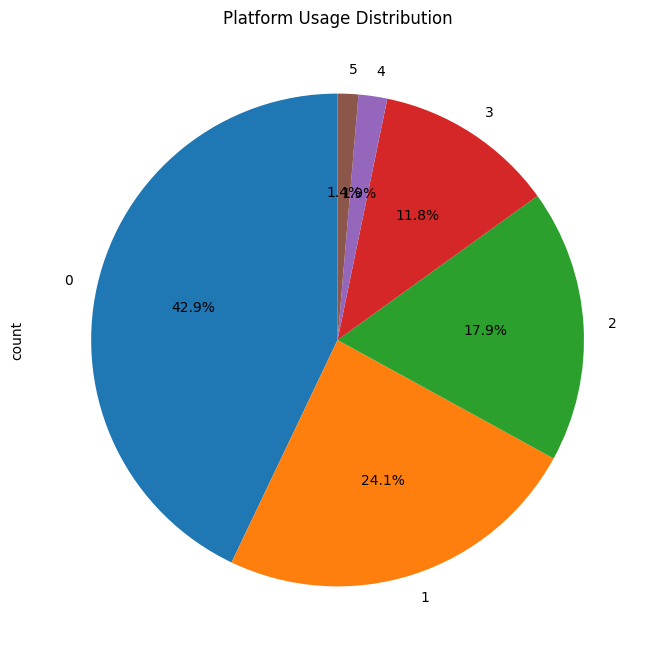

In [16]:
plt.figure(figsize=(8,8))
df["children"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    shadow=False
)
plt.title("Platform Usage Distribution")
plt.show()

#### Having 4 and 5 chhildrens are rare so there is not issue in data

<Axes: xlabel='smoker', ylabel='count'>

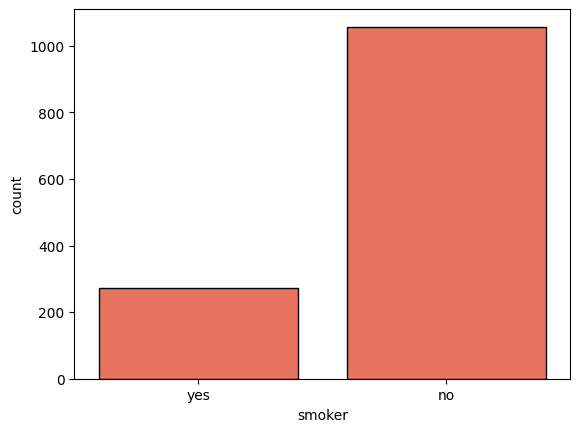

In [17]:
sns.countplot(x = df['smoker'],color='Tomato',edgecolor='black')

#### Majority of the Beneficiary are not smoker

<Axes: xlabel='region', ylabel='count'>

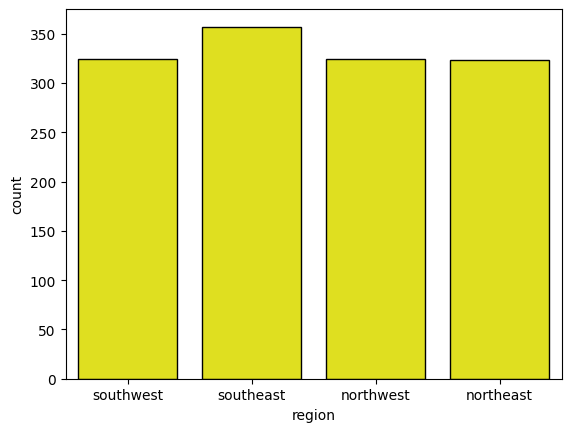

In [18]:
sns.countplot(x = df['region'],color='yellow',edgecolor='black')

#### Key Insight — Regional Balance
The four regions (Southeast, Southwest, Northwest, Northeast) are nearly uniformly distributed across the dataset. This balance ensures regional analysis is statistically fair, with no single region dominating the results.

<Axes: xlabel='charges'>

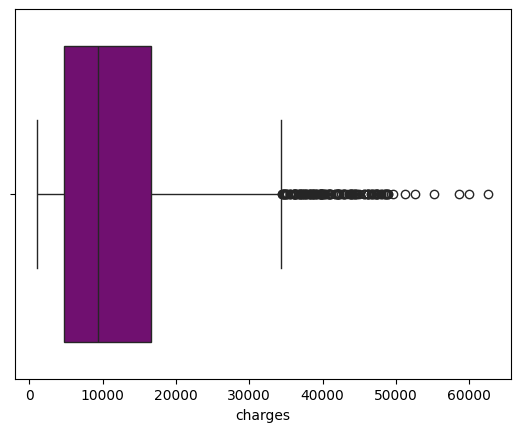

In [19]:
sns.boxplot(x = df['charges'],color='purple')

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

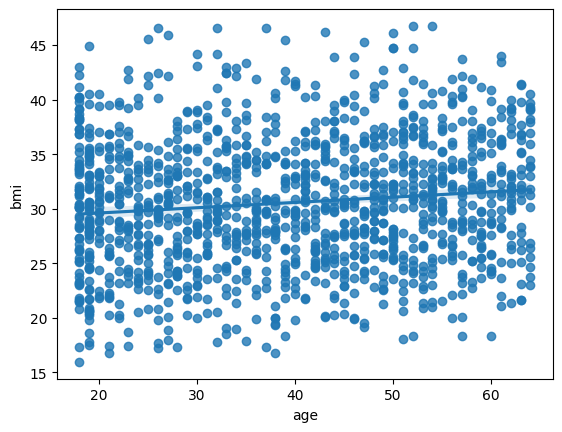

In [20]:
# Regression Plot : Age bs BMI
sns.regplot(data=df, x='age', y='bmi')
plt.show()

##### Age and BMI have a little positive correlation

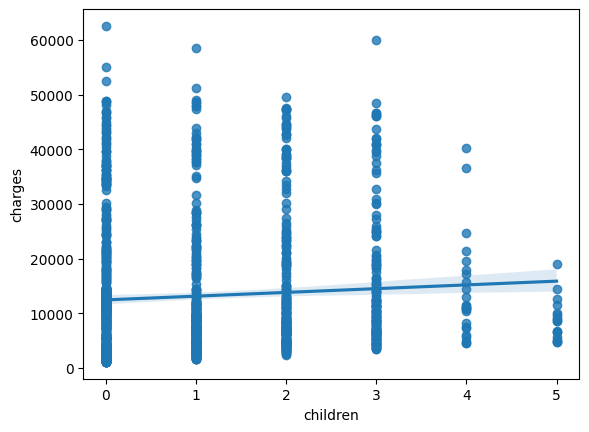

In [21]:
# Regression Plot : Children vs Charges
sns.regplot(data=df, x='children', y='charges')
plt.show()

##### More children means more insurance charge

### 3.2.2 Categorical vs Numerical

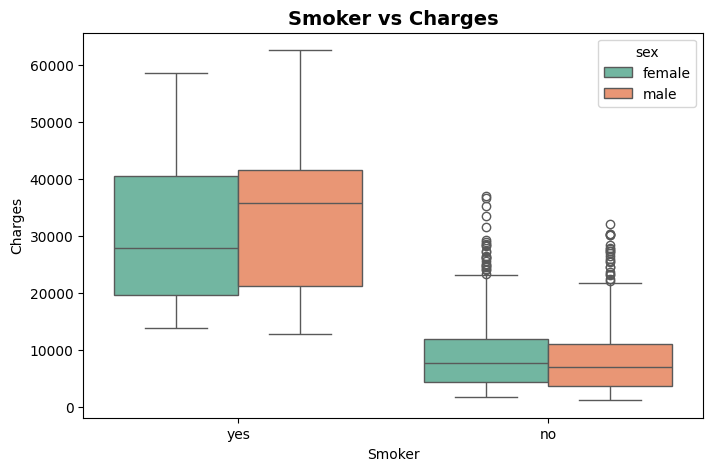

In [22]:
# Box Plot: Smoker vs Charges
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges", palette="Set2",hue='sex')
plt.title("Smoker vs Charges", fontsize=14, fontweight="bold")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

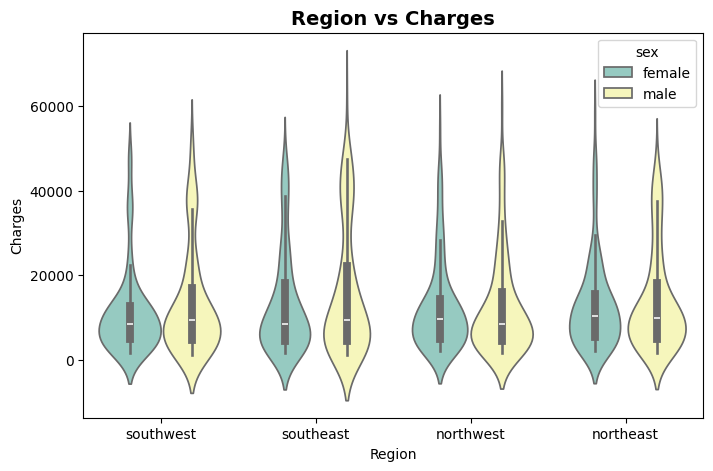

In [23]:
# Violin Plot: Region vs Charges
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="region", y="charges", palette="Set3",hue='sex')
plt.title("Region vs Charges", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Charges")
plt.show()

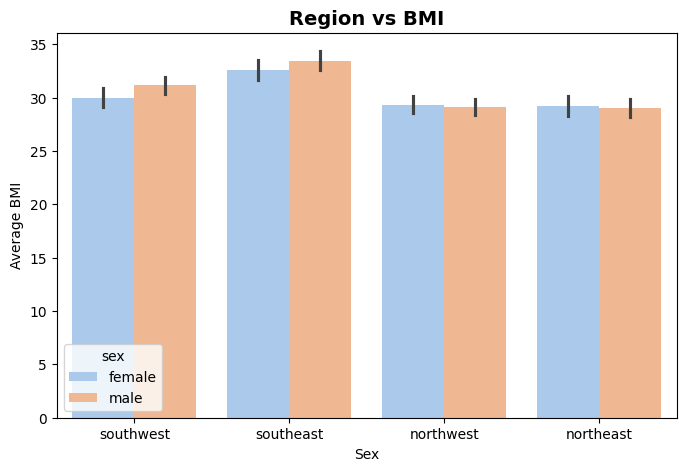

In [24]:
#  Bar Plot: Region vs BMI
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="region", y="bmi", palette="pastel",hue='sex')
plt.title("Region vs BMI", fontsize=14, fontweight="bold")
plt.xlabel("Sex")
plt.ylabel("Average BMI")
plt.show()

### 3.2.3 Categorical vs Categorical

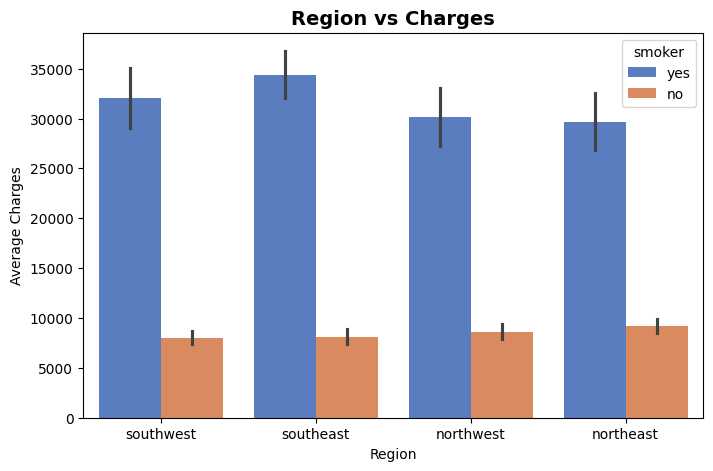

In [25]:
# Grouped Bar: Region vs Smoker
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="region", y="charges", palette="muted",hue='smoker')
plt.title("Region vs Charges", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Average Charges")
plt.show()

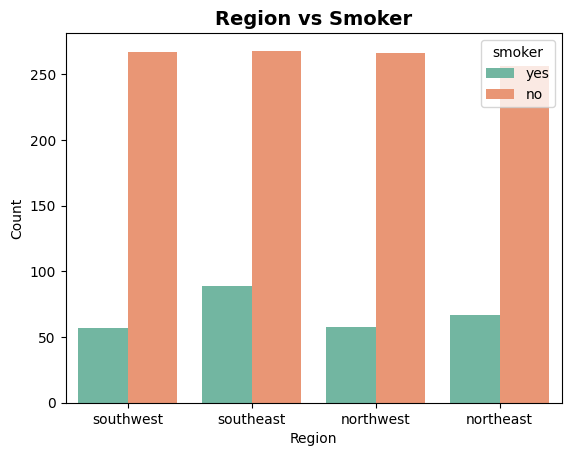

In [26]:
# Grouped Bar: Region vs Smoker
sns.countplot(data=df, x='region', hue='smoker', palette='Set2')

plt.title("Region vs Smoker",fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Count")

plt.show()

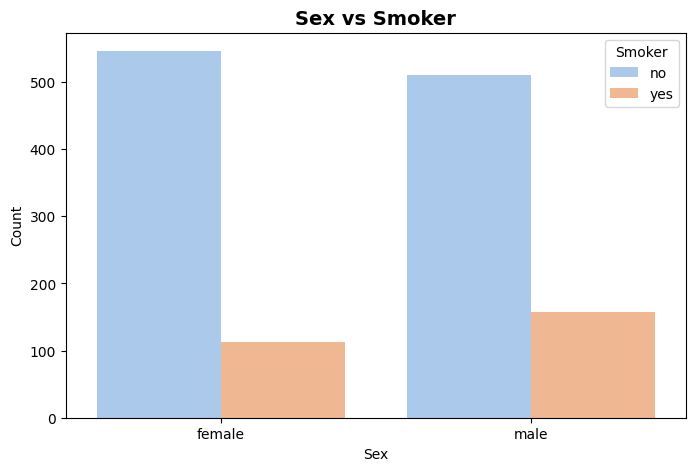

In [27]:
# Grouped Bar: Sex vs Smoker
sex_smoker = df.groupby(["sex", "smoker"]).size().reset_index(name="count")

plt.figure(figsize=(8, 5))
sns.barplot(data=sex_smoker, x="sex", y="count", hue="smoker", palette="pastel")
plt.title("Sex vs Smoker", fontsize=14, fontweight="bold")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Smoker")
plt.show()

### 3.3 Multivariate

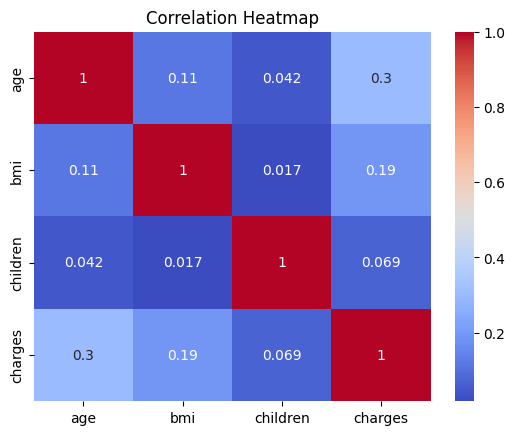

In [28]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# 4. Data Preprocessing

In [29]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [30]:
# Implementing OneHotEncoding -> Converting Categorical to numeric
df = pd.get_dummies(data=df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [31]:
# Splitting data so test data remained untouched
X = df.drop("charges", axis=1)
y = df["charges"]

In [32]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [33]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

cols_to_scale  = [c for c in X_train.columns  if X_train[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [34]:
X_train_df = pd.DataFrame(X_train)
X_train_df.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
414,-1.426075,0.766010,-0.895408,0,0,1,0,0
171,0.705211,-0.051678,-0.895408,1,0,0,0,1
947,-0.147304,0.605844,-0.071384,1,1,0,0,0
1013,0.634168,0.285513,-0.071384,1,0,1,0,0
210,-1.355032,0.403530,-0.071384,1,0,0,0,1


# 5. Machine Learning

In [35]:
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet  
from sklearn.neighbors import KNeighborsRegressor                             
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score

In [36]:
models = {
    "Linear Regression"          : LinearRegression(),
    "Lasso"                      : Lasso(),
    "Ridge"                      : Ridge(),
    "ElasticNet"                 : ElasticNet(),
    "KNeighbors Regressor"       : KNeighborsRegressor(),
    "Decision Tree Regressor"    : DecisionTreeRegressor(),
    "SVR"                        : SVR(),
    "Random Forest Regressor"    : RandomForestRegressor(n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor()
}

In [37]:
param_grids = {

    "Linear Regression": {
        "fit_intercept": [True, False]
    },

    "Lasso": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "Ridge": {
        "alpha": [0.01, 0.1, 1, 10, 100]
    },

    "ElasticNet": {
        "alpha"   : [0.01, 0.1, 1, 10],
        "l1_ratio": [0.2, 0.5, 0.7, 1.0]
    },

    "KNeighbors Regressor": {
        "n_neighbors": [3, 5, 7, 10, 15],
        "weights"    : ["uniform", "distance"]
    },

    "Decision Tree Regressor": {
        "max_depth"        : [None, 3, 5, 10, 20],
        "min_samples_split": [2, 5, 10]
    },

    "SVR": {
        "C"      : [0.1, 1, 10],
        "kernel" : ["linear", "rbf"],
        "epsilon": [0.1, 0.5, 1]
    },

    "Random Forest Regressor": {
        "n_estimators": [200,300],
        "max_depth"   : [5, 10]
    },

    "Gradient Boosting Regressor": {
        "n_estimators" : [200,300,400,500,600],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth"    : [3, 5,7]
    }

}

In [38]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [39]:
results = {}
best_models = {}

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=kf,
        scoring='r2', # r2 is for regression and 'accuracy' is for classification
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    # Store results
    results[name] = {
        "Best Params": grid.best_params_,
        "Best CV Score": grid.best_score_
    }

    # Store best trained model
    best_models[name] = grid.best_estimator_ 

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", round(grid.best_score_, 4))


Linear Regression
Best Params: {'fit_intercept': True}
Best CV Score: 0.7361

Lasso
Best Params: {'alpha': 100}
Best CV Score: 0.7373

Ridge
Best Params: {'alpha': 1}
Best CV Score: 0.7362

ElasticNet
Best Params: {'alpha': 10, 'l1_ratio': 1.0}
Best CV Score: 0.7363

KNeighbors Regressor
Best Params: {'n_neighbors': 3, 'weights': 'distance'}
Best CV Score: 0.7045

Decision Tree Regressor
Best Params: {'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.8362

SVR
Best Params: {'C': 10, 'epsilon': 0.5, 'kernel': 'linear'}
Best CV Score: -0.0448

Random Forest Regressor
Best Params: {'max_depth': 5, 'n_estimators': 300}
Best CV Score: 0.8512

Gradient Boosting Regressor
Best Params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}
Best CV Score: 0.8548


In [40]:
# DataFrame of results to make it more readable
results_df = pd.DataFrame(results)
results_df

,Linear Regression,Lasso,Ridge,ElasticNet,KNeighbors Regressor,Decision Tree Regressor,SVR,Random Forest Regressor,Gradient Boosting Regressor
Best Params,{'fit_intercept': True},{'alpha': 100},{'alpha': 1},"{'alpha': 10, 'l1_ratio': 1.0}","{'n_neighbors': 3, 'weights': 'distance'}","{'max_depth': 3, 'min_samples_split': 2}","{'C': 10, 'epsilon': 0.5, 'kernel': 'linear'}","{'max_depth': 5, 'n_estimators': 300}","{'learning_rate': 0.01, 'max_depth': 3, 'n_est..."
Best CV Score,0.736082,0.737346,0.736178,0.736331,0.704457,0.836207,-0.044757,0.851222,0.854772


In [41]:
best_model_name = max(
    results,
    key=lambda x: results[x]["Best CV Score"]
)

print("Best Model:", best_model_name)

Best Model: Gradient Boosting Regressor


In [42]:
'''We can also directly writes the best model nam by referring above DataFrame instead of creating a variable'''
best_grid = best_models[best_model_name] # Returns the best model object

In [43]:
best_estimator = best_grid

In [44]:
best_estimator

GradientBoostingRegressor(learning_rate=0.01, n_estimators=500)

In [45]:
y_pred = best_estimator.predict(X_test) 


In [46]:
# Print Regression Evaluation Metrics
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Test R² Score: {r2_score(y_test, y_pred):.4f}")

Test RMSE: 4605.3196
Test MSE: 21208968.2927
Test R² Score: 0.8474
